# Using Wikidata

Wikidata is a collaboratively maintained knowledge-base that is part of the larger Wikimedia universe and that includes more than 120,000,000 data entities. 
This data is also used to cross-link pages about the same subject across Wiki projects (like different language versions).

## Main concepts

The knowledge-base of Wikidata consists of **items** that are further described by having **properties** which can have different **values** (these **values** in turn can be **items** too). Together **properties** and **values** make up statements about a given **item**

The [*Introduction to Wikidata*](https://www.wikidata.org/wiki/Wikidata:Introduction) uses this example to make it less abstract, using the British Science Fiction writer Douglas Adams as an example:

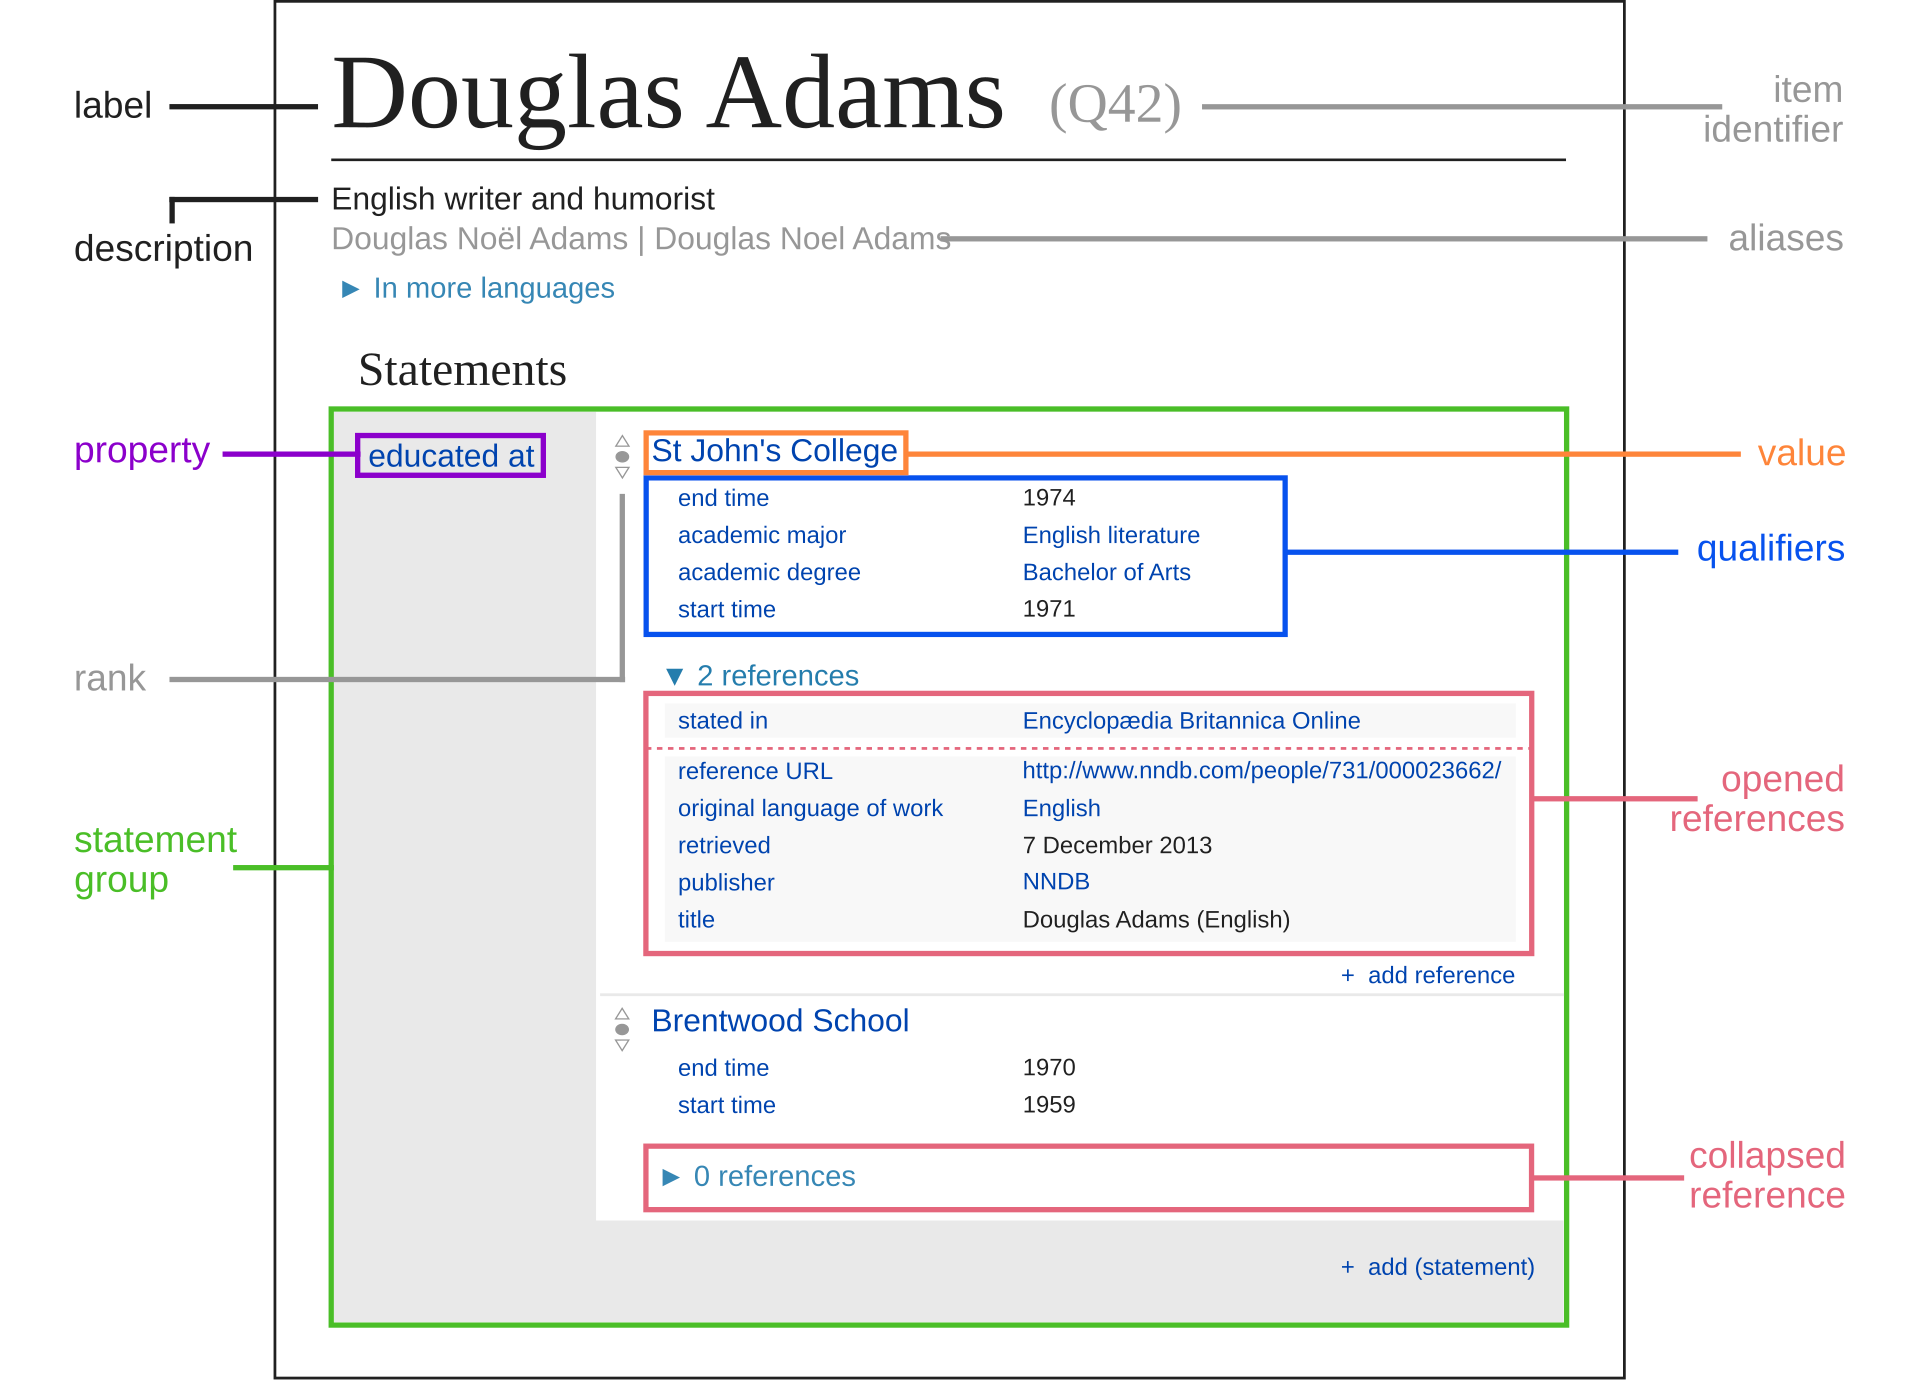

The highlighted statement (green) is about Adams' education, shown as the `educated_at` property (violet) and gives two values for this, `St John's College` (demonstrated in orange) and `Brentwood School`. In this case, both of these values are Wikidata items themselves. But in other cases, this could also just be a simple value, e.g. a date for the birth date.

Each of those statements can also be further qualified and supported by references, depending on the property in question. Qualifications, like seen here, could be start/end dates, degrees, titles and more. 

Wikidata can be queried using the [SPARQL query language](https://www.wikidata.org/wiki/Wikidata:SPARQL_query_service/Wikidata_Query_Help), which allows joining together required values for different properties to search for items.

## Motivation

When we tried to find all Kenyan politicians, we used the `Category:Kenyan politicians` category of the English language Wikipedia as our starting point. But, this is not ideal as it will include false-positives, in the form of pages that are not actually articles that describe politicians, and false-negatives - that is actual pages from Kenyan politicians might be missing because they aren't listed.

As an example for a false-positive when using the Category namespace: As there are many sub-categories for our category, we used `recursion=True` on the `Category:Kenyan politicians`, to make sure we get all the pages of politicians. But, our resulting list of pages surprisingly **also includes the page about the [Jomo Kenyatta International Airport](https://en.wikipedia.org/wiki/Jomo_Kenyatta_International_Airport)**! 

Why? It's because the page of the airport is part of the `Category:Jomo Kenyatta`, which in turn is part of `Category:Presidents of Kenya`, which in turn is part of `Category:Political office-holders in Kenya`, which - finally - is part of `Category:Kenyan politicians`.

## Wikidata queries to find all pages of a type

By writing a more narrow query for Wikidata, we can avoid such false-positives – and also get a whole range of cross-links between the different Wiki projects, e.g. to find the English, and Swahili editions of the same article.

## Writing a query

what properties and values could we use to find only Kenyan politicians?

1. The articles should be about *people*, not *airports*. So we can filter to find items that describe humans only. If we search for this in Wikidata, we find that the corresponding property/value translates to `P31` (*instance of*) and that *humans* are described by item `Q5`.
2. Now, to find politicians, we can filter by finding items that additionally give the *occupation* `P106` as *politician* (`Q82955`).
3. Lastly, we are looking for politicians that are from Kenya. One potential way to narrow it down to this could be filtering for the *country of citizenship* (`P27`) to be *Kenya* (`Q114`).

If we look at the [Wikidata item for Jomo Kenyatta](https://www.wikidata.org/wiki/Q173563), we find those properties showing up like this:

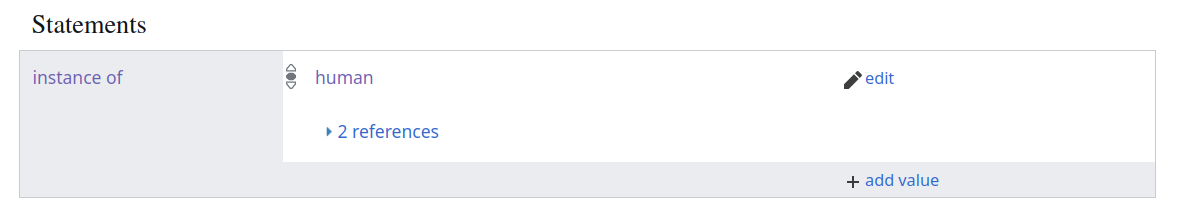

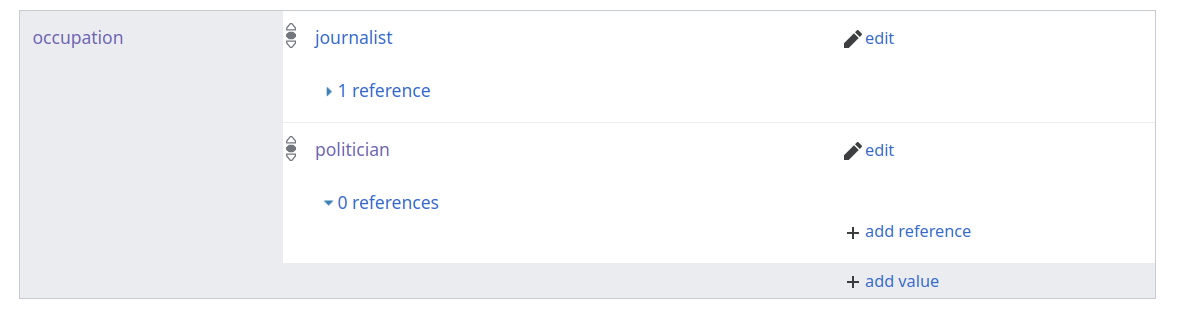

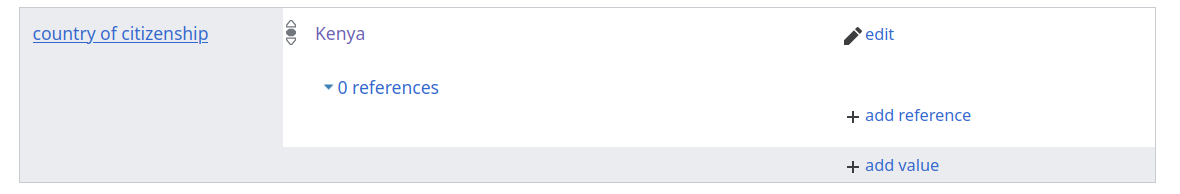

## Querying using `pywikibot`

Let's now translate this into creating a SPARQL query that the `pywikibot` can run for us. 

First, we load the necessary library again, and then we write out the query using the SPARQL syntax:

We use `SELECT DISTINCT` to avoid returning duplicate items, and use `?item` to get the whole Wikidata item returned for further processing.

In the `WHERE` clause, we add our three distinct property/value pairs that we all want to be present, and ultimately give a `LIMIT` of how many Wikidata items we'd like to get returned.

In [28]:
import pywikibot # load the whole library
# then we specifically import the page generator so we can iterate over all returned items
from pywikibot import pagegenerators as pg 

# we query Wikidata directly, not the english language Wikipedia
wikidata_site = pywikibot.Site("wikidata", "wikidata") 

# let's translate our query into SPARQL
QUERY = """
SELECT DISTINCT ?item
WHERE {
    ?item wdt:P31 wd:Q5;  # Any instance of a human;
          wdt:P106 wd:Q82955; # occupation politician;
          wdt:P27 wd:Q114; # citizen of kenya;
}
LIMIT 5
"""

Once we got this query written, we can now turn this into a generator, that will allow us to make a loop over all returned elements.

We will alrady look at some of the data we get back:

In [29]:
generator = pg.WikidataSPARQLPageGenerator(QUERY, site=wikidata_site)

for item in generator:
    print("item label (en): {}".format(
        item.labels['en']
    ))
    print("item description (en): {}".format(
        item.descriptions['en']
    ))
    print("sitelinks: {}".format(list(
        item.sitelinks
    )))
    print("sitelink to enwiki: {}".format(
        item.sitelinks["enwiki"]))
    print("----------")

item label (en): Robert Ouko
item description (en): politician (1931-1990)
sitelinks: ['arwiki', 'arzwiki', 'cawiki', 'commonswiki', 'dewiki', 'enwiki', 'eswiki', 'fiwiki', 'frwiki', 'glwiki', 'swwiki']
sitelink to enwiki: [[Robert Ouko (politician)]]
----------
item label (en): Mohamed Yusuf Haji
item description (en): Kenyan politician (1940–2021)
sitelinks: ['arwiki', 'dewiki', 'enwiki', 'swwiki', 'urwiki']
sitelink to enwiki: [[Mohamed Yusuf Haji]]
----------
item label (en): David Musila
item description (en): Kenyan politician
sitelinks: ['dewiki', 'enwiki']
sitelink to enwiki: [[David Musila]]
----------
item label (en): Elijah Masinde
item description (en): Kenyan footballer
sitelinks: ['dewiki', 'enwiki', 'swwiki']
sitelink to enwiki: [[Elijah Masinde]]
----------
item label (en): Bildad Kaggia
item description (en): Kenyan politician (1921-2005)
sitelinks: ['arzwiki', 'commonswiki', 'dewiki', 'enwiki', 'hawiki', 'idwiki', 'itwikiquote', 'sowiki', 'swwiki']
sitelink to enwiki:

For many items, the labels and descriptions will be available in multiple languages. Here, we printed only the English one. 

And as you see in the `sitelinks`, Wikidata also returns the cross-links to other Wiki projects, like the English (`enwiki`) and Swahili (`swwiki`) language editions of Wikipedia. This allows us now to switch to Wikipedia and read the articles as before:

## Exploring what the most common language editions are

Let's say we're interested to explore how different politicians are represented (or not) across language editions. While there's a large number of languages, let's pick a small subset of languages to work with for this example. If you have languages you're interest in, you can add them in the same format to the list, using the corresponding [2-letter ISO 639 language code](https://en.wikipedia.org/wiki/List_of_ISO_639_language_codes).

In [30]:
languages = [
    "enwiki",
    "swwiki",
    "dewiki",
    "frwiki",
    "eswiki",
]

Let's now expand our query a bit and get 10 entries for politicians instead of just 5, and then create a dataframe that contains the wiki-links for each of those combinations of politician & language-edition if present:

In [31]:
import pandas as pd # we'll need pandas to create the DF

QUERY = """
SELECT DISTINCT ?item
WHERE {
    ?item wdt:P31 wd:Q5;  # Any instance of a human;
          wdt:P106 wd:Q82955; # occupation politician;
          wdt:P27 wd:Q114; # citizen of kenya;
}
LIMIT 20
"""

generator = pg.WikidataSPARQLPageGenerator(QUERY, site=wikidata_site)

politicians = {} # create an empty dictionary that will hold the names as keys, and another dictionary with {'enwiki': '$pagename', …}

for item in generator:
    label = item.labels['en']
    politicians[label] = {}
    print('get languages for {}'.format(label))
    sitelinks = item.sitelinks
    for language in languages:
        if language in sitelinks.keys():
            politicians[label][language] = sitelinks[language].canonical_title()
        else:
            politicians[label][language] = ""

df_language_links = pd.DataFrame(politicians).T # use .T to transpose, so that policians are rows and languages are columns
df_language_links

get languages for Robert Ouko
get languages for McDonald Mariga
get languages for Harry Thuku
get languages for Richard Leakey
get languages for Wangari Muta Maathai
get languages for Bildad Kaggia
get languages for William Ruto
get languages for Uhuru Kenyatta
get languages for Moses Mudavadi
get languages for Mohamed Yusuf Haji
get languages for Daniel arap Moi
get languages for Elijah Lagat
get languages for Elijah Masinde
get languages for David Lelei
get languages for Jomo Kenyatta
get languages for Abdilatif Abdalla
get languages for Wesley Korir
get languages for David Musila
get languages for Grace Emily Akinyi Ogot
get languages for Newton Kulundu


,enwiki,swwiki,dewiki,frwiki,eswiki
Robert Ouko,Robert Ouko (politician),Robert Ouko,Robert Ouko (Politiker),Robert Ouko,Robert Ouko (político)
McDonald Mariga,McDonald Mariga,McDonald Mariga,McDonald Mariga,McDonald Mariga,McDonald Mariga
Harry Thuku,Harry Thuku,,Harry Thuku,Harry Thuku,
Richard Leakey,Richard Leakey,Richard Leakey,Richard Leakey,Richard Leakey,Richard Leakey
Wangari Muta Maathai,Wangarĩ Maathai,Wangari Maathai,Wangari Maathai,Wangari Muta Maathai,Wangari Maathai
Bildad Kaggia,Bildad Kaggia,Bildad Kaggia,Bildad Kaggia,,
William Ruto,William Ruto,William Ruto,William Ruto,William Ruto,William Ruto
Uhuru Kenyatta,Uhuru Kenyatta,Uhuru Kenyatta,Uhuru Kenyatta,Uhuru Kenyatta,Uhuru Kenyatta
Moses Mudavadi,Moses Mudavadi,,Moses Mudavadi,,
Mohamed Yusuf Haji,Mohamed Yusuf Haji,Mohamed Yusuf Haji,Yusuf Mohammed Haji,,


This gives us a nice data frame that includes all the links to the different pages acrosst the target languages. Why did we decide to keep the actual links as values instead of directly just making a binary "yes/no" evaluation? 

Because the actual names of the pages can differ between language editions, e.g. *Jaramogi Oginga Odinga* is the page name in the English Wikipedia, but in French & Spanish it's *Oginga Odinga*.
Which means if we want to keep working with the actual pages, we should keep those names to be able to query them.

But let's now make a small presence/absence Matrix:

In [32]:
pam_df = df_language_links.map(lambda x: int(bool(x))) # create presence/absence matrix

pam_df.style.background_gradient(cmap ='viridis',axis=None) # use axis=None to display heatmap calculated across whole DF

,enwiki,swwiki,dewiki,frwiki,eswiki
Robert Ouko,1,1,1,1,1
McDonald Mariga,1,1,1,1,1
Harry Thuku,1,0,1,1,0
Richard Leakey,1,1,1,1,1
Wangari Muta Maathai,1,1,1,1,1
Bildad Kaggia,1,1,1,0,0
William Ruto,1,1,1,1,1
Uhuru Kenyatta,1,1,1,1,1
Moses Mudavadi,1,0,1,0,0
Mohamed Yusuf Haji,1,1,1,0,0


This shows us some differences, both between individual politicians and the language editions, e.g. both the Spanish and Italian Wikipedias have fewer articles for this set of politicians. 

But how long are those articles? Let's convert this into looking at length, instead of presence/absence. First we need to set up the different `Site` objects for the different languages, so that we can query those.

And then we re-use our existing `politicians` dictionary to query the WP API for the corresponding page lengths, and save those in a dictionary that we can ultimately convert into a `DataFrame`.

**Note:** Querying all of those pages across language editions can take some time due to API limits.

In [33]:
language_sites = {} # let's store the site objects in a dict, so we can use them for our queries

for language in languages:
    language_sites[language] = pywikibot.Site(language[:2], 'wikipedia') # [:2] to get the language prefix

# for now we store the article lengths in a dict

article_lengths = {}

for politician in politicians:
    article_lengths[politician] = {}
    for language in politicians[politician]:
        if politicians[politician][language]:
            page = pywikibot.Page(language_sites[language], politicians[politician][language])
            article_lengths[politician][language] = len(page.text)
        else: # don't have a page, so length is zero
            article_lengths[politician][language] = 0

df_article_length = pd.DataFrame(article_lengths).T

Now that we got the data frame with article lengths, we can plot it as a heat map again. The heatmap was done over all cells. To better compare the lengths within a language, we now instead color by column, i.e. language edition:

In [34]:
df_article_length.style.background_gradient(cmap ='viridis',axis=0)

,enwiki,swwiki,dewiki,frwiki,eswiki
Robert Ouko,47295,7637,1867,14852,2641
McDonald Mariga,19981,4250,25325,7607,15887
Harry Thuku,13230,0,3704,12453,0
Richard Leakey,44530,3165,10229,8184,20600
Wangari Muta Maathai,76445,3211,22759,27246,61486
Bildad Kaggia,9495,823,3845,0,0
William Ruto,87709,8643,18334,19112,25521
Uhuru Kenyatta,120665,8931,24740,26056,11713
Moses Mudavadi,985,0,1033,0,0
Mohamed Yusuf Haji,10269,729,2022,0,0


## Working with claims

Now that we have seen how we can bridge between Wikidata items and Wikipedia pages, let us see how we can explore the Wikidata knowledge graph a bit more beyond just getting the objects and cross-links.

One thing that many Wikidata items about people contain, is the gender of the person they describe, which we need if we want to explore if Wikipedia articles describing people's biographies differ between gender of the person.
Inferring a person's gender is a fraught effort, and [misclassifications are not distributed amongst race or ethnicity](https://www.nature.com/articles/s41562-023-01587-9).
In Wikidata knowledge graph, gender is [represented by property `P21`](https://www.wikidata.org/wiki/Property:P21) (technically, Wikidata translates that to `sex or gender`), which would allow 

To get explore this, let's query a single politician using the same query as before and use that Wikidata item to explore the knowledge graph: 

In [35]:
QUERY = """
SELECT DISTINCT ?item
WHERE {
    ?item wdt:P31 wd:Q5;  # Any instance of a human;
          wdt:P106 wd:Q82955; # occupation politician;
          wdt:P27 wd:Q114; # citizen of kenya;
}
LIMIT 1
"""

generator = pg.WikidataSPARQLPageGenerator(QUERY, site=wikidata_site)

wikidata_item = generator.__next__() # to just emit the single response

print('got {} as politician'.format(wikidata_item.labels['en']))   


got Bildad Kaggia as politician


Now that we got our wikidata item, let's find out if it contains claim about the person's gender:

In [36]:
# p21: gender
# [0] get the first claim for this property - for some properties there could be multiple claims!
# target: Get the value of that claim - can be an item too
# label: get english name of item, i.e. gender marker in english

wikidata_item.claims['P21'][0].target.labels['en']

'male'

Let's look at this step by step:

* `.claims['P21'] asks to get **all** values of this property for our Wikidata item of interest. Items can have zero to many claims for a given property. We need to consider this when doing error handling.
* `[0]` - we are interested in only looking at the first value for this property, in case there'd be multiple. Of course, depending on the property, we could be interested at looking at all of them!
* `.target` gives us the actual value of that claim. For `gender` this will be another Wikidata item, which has translatable labels

## Bringing it together

Now, let's try to get a set of politicians, their gender according to Wikidata and then get the page lengths for the diferrent language editions. We can then do a simple comparison between article length and gender in those languages:

In [38]:
QUERY = """
SELECT DISTINCT ?item
WHERE {
    ?item wdt:P31 wd:Q5;  # Any instance of a human;
          wdt:P106 wd:Q82955; # occupation politician;
          wdt:P27 wd:Q114; # citizen of kenya;
}
LIMIT 10
"""


LANGUAGES = [
    "enwiki",
    "swwiki",
    "dewiki",
    "frwiki",
    "eswiki",
]

LANGUAGE_SITES = {} # let's store the site objects in a dict, so we can use them for our queries

for language in LANGUAGES:
    LANGUAGE_SITES[language] = pywikibot.Site(language[:2], 'wikipedia') # [:2] to get the language prefix



# Let's wrap some of the code we wrote above into functions, to make it easier to call and ultimately merge it into a dataframe at the end!

def get_gender(wikidata_item):
    if "P21" in wikidata_item.claims.keys():
        return wikidata_item.claims['P21'][0].target.labels['en']
    else:
        return "unknown"


def run_query(QUERY):
    generator = pg.WikidataSPARQLPageGenerator(QUERY, site=wikidata_site)

    politician_data = {}

    for item in generator:
        qid = item.getID() # get unique ID
        politician_data[qid] = {} # initialize dictionary 
        politician_data[qid]['gender'] = get_gender(item) # add gender
        politician_data[qid]['label'] = item.labels['en'] # add english label
        print('get languages for {}'.format(qid))
        sitelinks = item.sitelinks
        for language in LANGUAGES:
            if language in sitelinks.keys():
                page_title = sitelinks[language].canonical_title()
                page = pywikibot.Page(LANGUAGE_SITES[language], page_title)
                politician_data[qid][language] = len(page.text)
            else: # don't have a page, so length is zero
                politician_data[qid][language] = 0
    return politician_data

In [39]:
politician_data = run_query(QUERY)
pd.DataFrame(politician_data).T

get languages for Q469641
get languages for Q982715
get languages for Q457713
get languages for Q1030776
get languages for Q447119
get languages for Q1175814
get languages for Q346046
get languages for Q1121940
get languages for Q860562
get languages for Q456466


,gender,label,enwiki,swwiki,dewiki,frwiki,eswiki
Q469641,female,Grace Emily Akinyi Ogot,16605,4621,4682,8000,0
Q982715,male,Robert Ouko,47295,7637,1867,14852,2641
Q457713,male,Newton Kulundu,4786,0,3386,0,0
Q1030776,male,Mohamed Yusuf Haji,10269,729,2022,0,0
Q447119,male,Wesley Korir,16755,0,3663,9470,0
Q1175814,male,David Musila,6949,0,1982,0,0
Q346046,male,Elijah Lagat,12397,1091,4760,0,5463
Q1121940,male,Elijah Masinde,3430,4331,7478,0,0
Q860562,male,Bildad Kaggia,9495,823,3845,0,0
Q456466,male,David Lelei,5151,0,1779,3847,4818


While this form of querying works, it shows quite a heavy gender bias (which could be in politics, in Wikipedia, or both?). Either way, by querying without gender, we end up with an overwhelmingly male data set.

To be able to actually make a comparison, let's do two queries instead, one for male and one for female politicians:

In [70]:
male_query = """
SELECT DISTINCT ?item
WHERE {
    ?item wdt:P31 wd:Q5;  # Any instance of a human;
          wdt:P106 wd:Q82955; # occupation politician;
          wdt:P27 wd:Q114; # citizen of kenya;
          wdt:P21 wd:Q6581097; # male
}
LIMIT 20
"""

female_query = """
SELECT DISTINCT ?item
WHERE {
    ?item wdt:P31 wd:Q5;  # Any instance of a human;
          wdt:P106 wd:Q82955; # occupation politician;
          wdt:P27 wd:Q114; # citizen of kenya;
          wdt:P21 wd:Q6581072; # female
}
LIMIT 20
"""


male_politicians = run_query(male_query)
female_politicians = run_query(female_query)



get languages for Q1372633
get languages for Q313893
get languages for Q733180
get languages for Q58188
get languages for Q57657
get languages for Q202077
get languages for Q733817
get languages for Q645228
get languages for Q1395018
get languages for Q318960
get languages for Q593552
get languages for Q710549
get languages for Q195725
get languages for Q196070
get languages for Q121708
get languages for Q57291
get languages for Q193492
get languages for Q173563
get languages for Q308189
get languages for Q1441663
get languages for Q111188237
get languages for Q111188303
get languages for Q20022486
get languages for Q110612580
get languages for Q7966924
get languages for Q111188275
get languages for Q21064137
get languages for Q21062983
get languages for Q539821
get languages for Q111188214
get languages for Q46795
get languages for Q565671
get languages for Q111188217
get languages for Q111188213
get languages for Q111188327
get languages for Q8025655
get languages for Q12170059
get l

Now we can merge the two dictionaries and create one dataframe:

In [71]:
all_politicians = female_politicians | male_politicians
df_all_politicians = pd.DataFrame(all_politicians).T
df_all_politicians

,gender,label,enwiki,swwiki,dewiki,frwiki,eswiki
Q111188237,female,Hellen Sambili,0,0,0,0,0
Q111188303,female,Mary Emaase Otuch,3305,1227,0,0,0
Q20022486,female,Rosalyn Nandwa,2875,1197,0,0,0
Q110612580,female,Josephine Sinyo,4408,1265,0,0,0
Q7966924,female,Wambui Otieno,27335,1700,0,0,0
Q111188275,female,Jane Agnes Wanjira Machira,0,0,0,0,0
Q21064137,female,Rachel Ruto,6247,0,0,10030,0
Q21062983,female,Marianne Jebet Kitany,6520,0,0,0,0
Q539821,female,Charity Ngilu,23356,1772,2740,10607,1800
Q111188214,female,Alice Wambui Ng'ang'a,3519,1291,0,0,0


Now let's try plotting this as a boxplot, grouping by gender for each of the languages:

dewiki    Axes(0.125,0.747241;0.775x0.132759)
enwiki    Axes(0.125,0.587931;0.775x0.132759)
eswiki    Axes(0.125,0.428621;0.775x0.132759)
frwiki     Axes(0.125,0.26931;0.775x0.132759)
swwiki        Axes(0.125,0.11;0.775x0.132759)
dtype: object

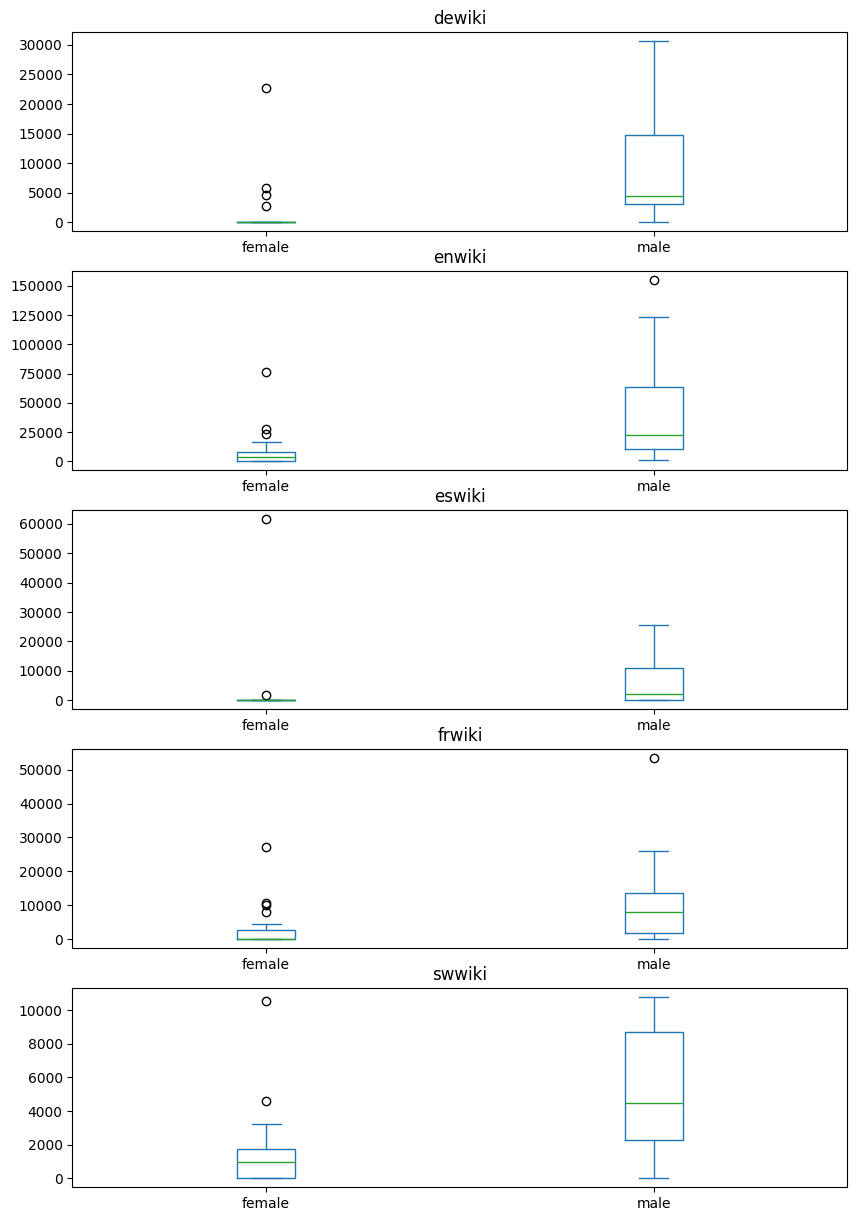

In [72]:
df_all_politicians.plot(kind='box',column=LANGUAGES, by=["gender"],layout=(5, 1),figsize=(10,15))

## Exploring the difference in number of pages by gender

Let's also investigate how large the difference in number of recorded items is for male & female politicians in Wikidata. For that we can run two queries to just get the number of items:

```
SELECT DISTINCT (COUNT(?item) as ?count) # get count of items instead of actual pages
WHERE {
    ?item wdt:P31 wd:Q5;  # Any instance of a human;
          wdt:P106 wd:Q82955; # occupation politician;
          wdt:P27 wd:Q114; # citizen of kenya;
          wdt:P21 wd:Q6581097; # male
}
```

and

```
SELECT DISTINCT (COUNT(?item) as ?count) # get count of items instead of actual pages
WHERE {
    ?item wdt:P31 wd:Q5;  # Any instance of a human;
          wdt:P106 wd:Q82955; # occupation politician;
          wdt:P27 wd:Q114; # citizen of kenya;
          wdt:P21 wd:Q6581072; # female
}
```

We can run these directly using the Wikidata Query Service, without having to write code (e.g. for [male](https://query.wikidata.org/#SELECT%20DISTINCT%20%28COUNT%28%3Fitem%29%20as%20%3Fcount%29%0AWHERE%20%7B%0A%20%20%20%20%3Fitem%20wdt%3AP31%20wd%3AQ5%3B%20%20%23%20Any%20instance%20of%20a%20human%3B%0A%20%20%20%20%20%20%20%20%20%20wdt%3AP106%20wd%3AQ82955%3B%20%23%20occupation%20politician%3B%0A%20%20%20%20%20%20%20%20%20%20wdt%3AP27%20wd%3AQ114%3B%20%23%20citizen%20of%20kenya%3B%0A%20%20%20%20%20%20%20%20%20%20wdt%3AP21%20wd%3AQ6581097%3B%20%23%20male%0A%7D) and [female](https://query.wikidata.org/#SELECT%20DISTINCT%20%28COUNT%28%3Fitem%29%20as%20%3Fcount%29%0AWHERE%20%7B%0A%20%20%20%20%3Fitem%20wdt%3AP31%20wd%3AQ5%3B%20%20%23%20Any%20instance%20of%20a%20human%3B%0A%20%20%20%20%20%20%20%20%20%20wdt%3AP106%20wd%3AQ82955%3B%20%23%20occupation%20politician%3B%0A%20%20%20%20%20%20%20%20%20%20wdt%3AP27%20wd%3AQ114%3B%20%23%20citizen%20of%20kenya%3B%0A%20%20%20%20%20%20%20%20%20%20wdt%3AP21%20wd%3AQ6581072%3B%20%23%20female%0A%7D) politicians): This shows us that there are 224 items for female politicians, and 915 items for male politicians.

## Using some very basic NLP to identify a gender from a Wikipedia page

So far, we have used the gender information as directly supplied by Wikidata (and even explicitly filtered for the presence of the information). 
But potentially this information is not present in all Wikidata items describing politicians. 

Plus, if we think back to just querying category pages - we might want to also use Wikipedia pages directly, without expecting or needing a corresponding Wikidata item.
How could we assign gender in that case? A ver simple example would be to [count the pronouns](https://en.wikipedia.org/wiki/Pronouns_in_English) in each page and use those to assign gender.

We can try to explore how well such an approach would work by using our existing set of politicians, loading the (English) articles and giving it a try:


In [74]:
wikidata_site = language_sites['enwiki'].data_repository() # setup wikidata site object

pronouns_female = ['she', 'her', 'herself', 'hers']
pronouns_male = ['he', 'him', 'himself', 'his']

pronoun_female_count = []
pronoun_male_count = []

for qid in df_all_politicians.index: # iterate over all qid which we so far used as df index
    if 'enwiki' in pywikibot.ItemPage(wikidata_site, qid).sitelinks.keys(): # not all wikidata items have english language articles
        article_title = pywikibot.ItemPage(wikidata_site, qid).sitelinks['enwiki'].canonical_title() # get english page title
        page = pywikibot.Page(LANGUAGE_SITES['enwiki'], article_title) # get article text 
        page_text = page.text.lower() # make lower case to simplify matching
    
        # sum up female pronoun counts, add to list 
        counts_female = 0
        for p in pronouns_female:
            counts_female += page_text.count(" {} ".format(p)) # require space before/after pronoun
        pronoun_female_count.append(counts_female)
    
        # sum up female pronoun counts, add to list
        counts_male = 0
        for p in pronouns_male:
            counts_male += page_text.count(" {} ".format(p))
        pronoun_male_count.append(counts_male)
    else:
        pronoun_female_count.append(0)
        pronoun_male_count.append(0)


# add pronouns to DF
df_all_politicians['pronoun_female_count'] = pronoun_female_count
df_all_politicians['pronoun_male_count'] = pronoun_male_count

In [86]:
df_all_politicians

,gender,label,enwiki,swwiki,dewiki,frwiki,eswiki,pronoun_female_count,pronoun_male_count
Q111188237,female,Hellen Sambili,0,0,0,0,0,0,0
Q111188303,female,Mary Emaase Otuch,3305,1227,0,0,0,15,0
Q20022486,female,Rosalyn Nandwa,2875,1197,0,0,0,6,0
Q110612580,female,Josephine Sinyo,4408,1265,0,0,0,10,1
Q7966924,female,Wambui Otieno,27335,1700,0,0,0,75,65
Q111188275,female,Jane Agnes Wanjira Machira,0,0,0,0,0,0,0
Q21064137,female,Rachel Ruto,6247,0,0,10030,0,13,1
Q21062983,female,Marianne Jebet Kitany,6520,0,0,0,0,17,1
Q539821,female,Charity Ngilu,23356,1772,2740,10607,1800,45,5
Q111188214,female,Alice Wambui Ng'ang'a,3519,1291,0,0,0,9,1


Now we got the absolute counts. For demonstration purposes, let's now just make a very simple classifer, in which we assign the gender based on simple majority:

In [88]:
def assign_gender(row):
    if row['pronoun_male_count'] != 0 and row['pronoun_male_count'] != 0: 
        ratio = row['pronoun_female_count'] / row['pronoun_male_count']
        if ratio > 1:
            return 'female'
        else:
            return 'male'
    elif row['pronoun_male_count'] != 0:
        return 'male'
    else:
        return 'female'
    


df_all_politicians['gender_nlp'] = df_all_politicians.apply(assign_gender,axis=1)

We can now compare if the wikidata label and our prediction agree:

In [89]:
df_all_politicians['gender'] == df_all_politicians['gender_nlp']

Q111188237    True
Q111188303    True
Q20022486     True
Q110612580    True
Q7966924      True
Q111188275    True
Q21064137     True
Q21062983     True
Q539821       True
Q111188214    True
Q46795        True
Q565671       True
Q111188217    True
Q111188213    True
Q111188327    True
Q8025655      True
Q12170059     True
Q110160494    True
Q111188215    True
Q469641       True
Q1372633      True
Q313893       True
Q733180       True
Q58188        True
Q57657        True
Q202077       True
Q733817       True
Q645228       True
Q1395018      True
Q318960       True
Q593552       True
Q710549       True
Q195725       True
Q196070       True
Q121708       True
Q57291        True
Q193492       True
Q173563       True
Q308189       True
Q1441663      True
dtype: bool